# Notebook 03 — ACP et clustering

Objectif : utiliser l'ACP pour visualiser les actions, puis K-Means et CAH pour les regrouper.

À la fin de ce notebook, on obtient :
- projection ACP
- clusters K-Means
- dendrogramme CAH
- tableau final avec les groupes

Remarque : CAH c'est classification ascendante hiérarchique

In [2]:
# importer les bibliothèques
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

os.makedirs("../figures", exist_ok=True)

indicateurs = pd.read_csv("../data/obtenue/indicateurs_actions.csv", index_col=0)
indicateurs

,rendement_moyen_annuel,volatilite_annuelle,rendement_min_journalier,rendement_max_journalier,correlation_CAC40
TTE.PA,0.129379,0.304387,-0.166083,0.150742,0.660793
SU.PA,0.218439,0.299061,-0.140180,0.120130,0.768534
MC.PA,0.131210,0.303992,-0.086779,0.128119,0.779378
AI.PA,0.110667,0.208582,-0.111603,0.082596,0.726724
SAN.PA,0.052344,0.233065,-0.189329,0.084405,0.402857
AIR.PA,0.155409,0.396552,-0.221685,0.204633,0.730943
SAF.PA,0.205461,0.379744,-0.228737,0.209327,0.752658
BNP.PA,0.184088,0.343259,-0.135203,0.179807,0.769486
OR.PA,0.098581,0.247306,-0.075803,0.084374,0.673341
CS.PA,0.170059,0.268402,-0.152184,0.175640,0.788181


## 1. Normalisation des données

Les variables n'ont pas la même échelle. Par exemple, la volatilité et la corrélation ne se lisent pas de la même manière.
On utilise donc `StandardScaler` pour mettre toutes les variables sur une échelle comparable.

In [3]:
# TODO par tareq
X = indicateurs.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.1572629 ,  0.11231638, -0.48974699,  0.27771469, -0.54235791],
       [ 1.21368431,  0.00691237,  0.05113025, -0.43966929,  0.61926514],
       [-0.12907359,  0.10450106,  1.16616926, -0.25244397,  0.73618201],
       [-0.44530699, -1.78392362,  0.64782099, -1.31926682,  0.16848567],
       [-1.34309709, -1.29933127, -0.97512729, -1.27686716, -3.32332879]])

## 2. ACP

L'ACP réduit les 5 indicateurs à 2 axes principaux afin de visualiser les actions sur un plan.

In [4]:
# TODO par karim
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["Axe 1", "Axe 2"],
    index=indicateurs.index
)

print("Variance expliquée par les deux axes :")
print(pca.explained_variance_ratio_)
print("Variance totale expliquée :", pca.explained_variance_ratio_.sum())

pca_df

Variance expliquée par les deux axes :
[0.51825315 0.26682179]
Variance totale expliquée : 0.78507493706629


,Axe 1,Axe 2
TTE.PA,0.179935,-0.716058
SU.PA,0.280570,1.117239
MC.PA,-0.333843,0.999010
AI.PA,-2.036000,0.618603
SAN.PA,-2.628753,-2.880795
AIR.PA,2.742528,-1.116354
SAF.PA,2.989465,-0.576211
BNP.PA,1.383379,0.604692
OR.PA,-2.178987,0.463872
CS.PA,0.711950,0.657585


## 3. Graphique ACP


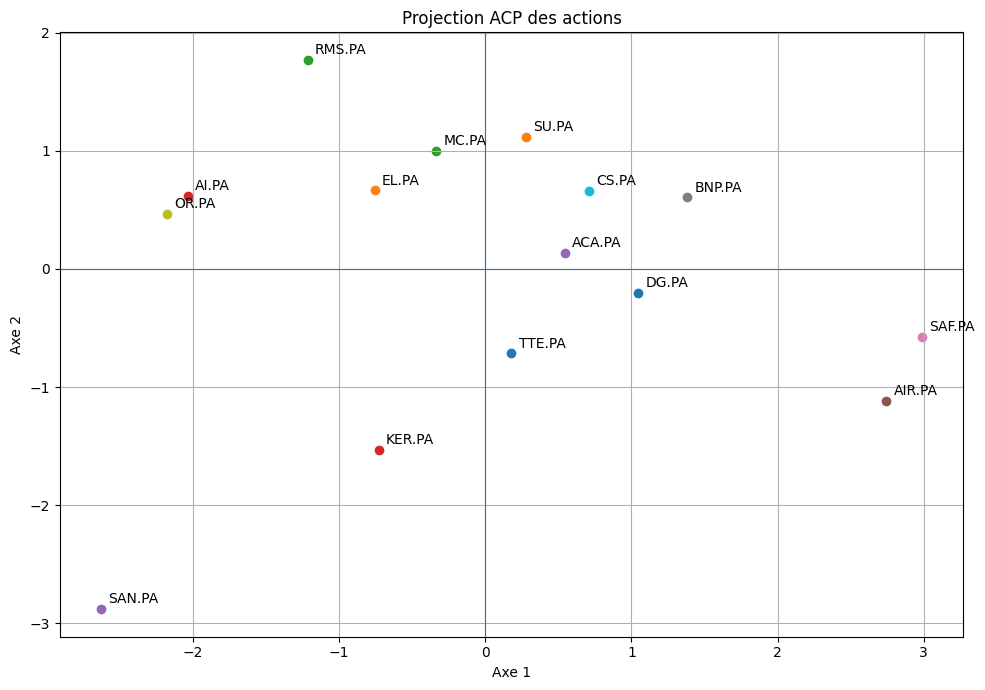

In [5]:
# TODO par tareq
plt.figure(figsize=(10, 7))

for action in pca_df.index:
    plt.scatter(pca_df.loc[action, "Axe 1"], pca_df.loc[action, "Axe 2"])
    plt.text(
        pca_df.loc[action, "Axe 1"] + 0.05,
        pca_df.loc[action, "Axe 2"] + 0.05,
        action
    )

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel("Axe 1")
plt.ylabel("Axe 2")
plt.title("Projection ACP des actions")
plt.grid(True)
plt.tight_layout()
plt.savefig("../figures/acp_actions.png", dpi=300)
plt.show()

## 4. Contribution des variables aux axes

Cela aide à interpréter les axes de l'ACP.

In [6]:
# TODO par karim
test = pd.DataFrame(
    pca.components_.T,
    columns=["Axe 1", "Axe 2"],
    index=X.columns
)

test

,Axe 1,Axe 2
rendement_moyen_annuel,0.271357,0.573199
volatilite_annuelle,0.522506,-0.167942
rendement_min_journalier,-0.408099,0.553981
rendement_max_journalier,0.591927,-0.090087
correlation_CAC40,0.369365,0.572911


## 5. K-Means

On choisit 3 clusters pour garder une interprétation simple :
- groupe stable
- groupe intermédiaire
- groupe plus risqué / particulier

In [7]:
# TODO par tareq
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

resultats = indicateurs.copy()
resultats["cluster_kmeans"] = clusters

pca_df["cluster_kmeans"] = clusters

resultats.sort_values("cluster_kmeans")

,rendement_moyen_annuel,volatilite_annuelle,rendement_min_journalier,rendement_max_journalier,correlation_CAC40,cluster_kmeans
AI.PA,0.110667,0.208582,-0.111603,0.082596,0.726724,0
MC.PA,0.131210,0.303992,-0.086779,0.128119,0.779378,0
EL.PA,0.165868,0.267639,-0.103898,0.129790,0.688707,0
OR.PA,0.098581,0.247306,-0.075803,0.084374,0.673341,0
RMS.PA,0.235355,0.278957,-0.065414,0.091043,0.689189,0
AIR.PA,0.155409,0.396552,-0.221685,0.204633,0.730943,1
SU.PA,0.218439,0.299061,-0.140180,0.120130,0.768534,1
TTE.PA,0.129379,0.304387,-0.166083,0.150742,0.660793,1
DG.PA,0.106035,0.292405,-0.170744,0.188469,0.792284,1
BNP.PA,0.184088,0.343259,-0.135203,0.179807,0.769486,1


## 6. Graphique ACP coloré par cluster

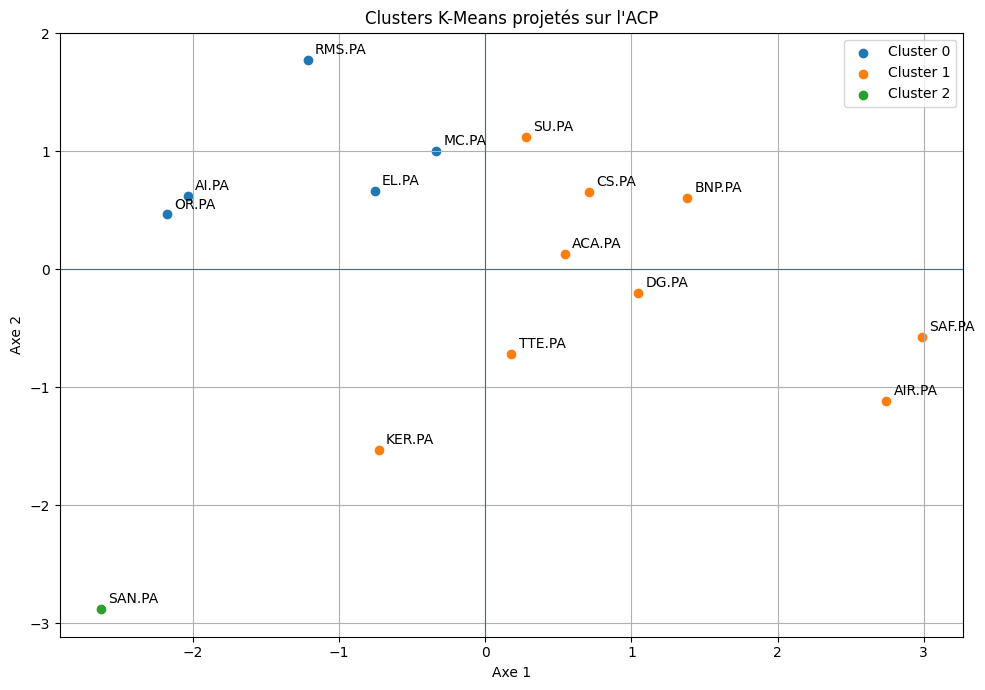

In [12]:
# TODO par tareq
plt.figure(figsize=(10, 7))

for cluster in sorted(pca_df["cluster_kmeans"].unique()):
    subset = pca_df[pca_df["cluster_kmeans"] == cluster]
    plt.scatter(subset["Axe 1"], subset["Axe 2"], label=f"Cluster {cluster}")

    for action in subset.index:
        plt.text(
            subset.loc[action, "Axe 1"] + 0.05,
            subset.loc[action, "Axe 2"] + 0.05,
            action
        )

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel("Axe 1")
plt.ylabel("Axe 2")
plt.title("Clusters K-Means projetés sur l'ACP")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("../figures/clusters_kmeans.png", dpi=300)
plt.show()

## 7. Profil moyen de chaque cluster

Faire un tableau , et ce tableau est très important pour le rapport.
Il permet de dire si un cluster est plutôt risqué, stable, rentable, etc.

In [9]:
# TODO par karim

## 8. CAH : classification ascendante hiérarchique

La CAH permet de visualiser les distances entre actions avec un dendrogramme.

In [10]:
# TODO par karim

## 9. Sauvegarde du tableau final

In [11]:
# TODO par tareq

## 10. resultat finale


                   faire par karim et tareq